In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models


In [3]:
def generate_sine_wave_data(seq_length, num_samples):
    x = np.linspace(0, num_samples * 0.1, num_samples)
    y = np.sin(x)
    data = []
    for i in range(num_samples - seq_length):
        data.append(y[i:i+seq_length+1])
    data = np.array(data)
    return data[:, :-1], data[:, -1]

# 데이터셋 생성
seq_length = 50
num_samples = 1000
x, y = generate_sine_wave_data(seq_length, num_samples)

# 데이터셋 분할 (80% 학습, 20% 테스트)
train_size = int(len(x) * 0.8)
x_train, y_train = x[:train_size], y[:train_size]
x_test, y_test = x[train_size:], y[train_size:]

# 입력 데이터를 RNN이 처리할 수 있는 형식으로 변환
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))


In [4]:
# RNN 모델 구성
model = models.Sequential([
    layers.SimpleRNN(50, activation='relu', input_shape=(seq_length, 1)),
    layers.Dense(1)
])

# 모델 컴파일
model.compile(optimizer='adam', loss='mse')

# 모델 요약 출력
model.summary()


2024-06-10 14:06:11.377492: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2024-06-10 14:06:11.377559: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2024-06-10 14:06:11.377575: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2024-06-10 14:06:11.377643: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-06-10 14:06:11.377673: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/bumsuklee/miniconda3/envs/llmserver-3.11-llm/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 모델 학습
history = model.fit(x_train, y_train, epochs=20, validation_data=(x_test, y_test))


Epoch 1/20


2024-06-10 14:06:24.607017: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 363ms/step - loss: 0.5906 - val_loss: 0.1135
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 342ms/step - loss: 0.0701 - val_loss: 0.0136
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 342ms/step - loss: 0.0111 - val_loss: 0.0051
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 344ms/step - loss: 0.0039 - val_loss: 0.0011
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 348ms/step - loss: 7.0912e-04 - val_loss: 2.3933e-04
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 357ms/step - loss: 1.8397e-04 - val_loss: 6.5346e-05
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 359ms/step - loss: 5.2200e-05 - val_loss: 2.4107e-05
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 381ms/step - loss: 2.1691e-05 - val_loss: 2.3344e-05
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 353ms/step - loss: 2.0157e-05 - val_loss: 1.8470e-05
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 368ms/step - loss: 1.5945e-05 - val_loss: 1.2619e-05
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 363ms/step - loss: 1.4870e-05 - val_loss: 1.1583e-05
Epoch 

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


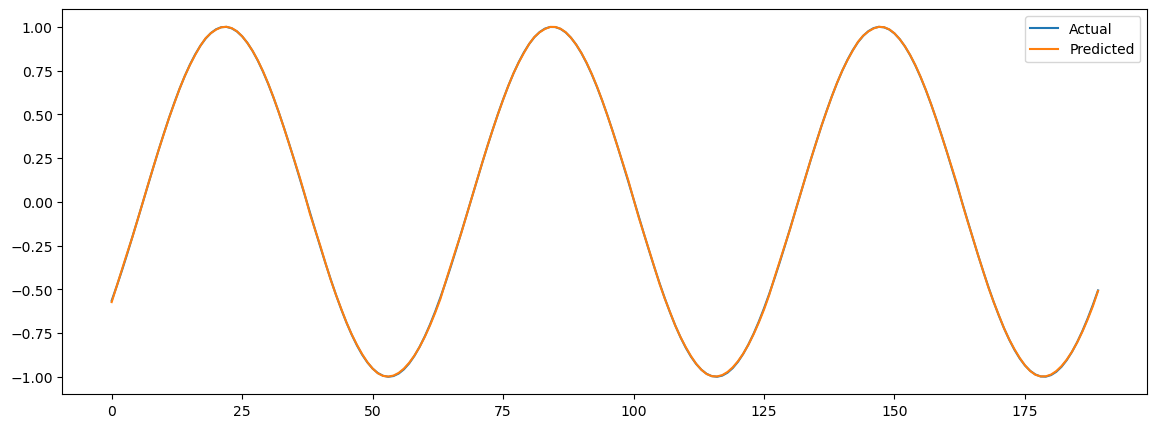

In [6]:
# 테스트 데이터에 대한 예측
y_pred = model.predict(x_test)

# 예측 결과 시각화
plt.figure(figsize=(14, 5))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()
